# Modeling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

## Preparing the Data

In [2]:
news = pd.read_parquet("/home/jupyter-sc2641/Varshini_FP/5650-local-news-and-climate-change/cc_labels_and_share.parquet")
news.head()

,state,wave,neutral,opportunity,risk,total,risk_share,opportunity_share,neutral_share,balance,volume_by_state_wave,total_volume_by_state_wave,coverage_share
0,Alabama,wave 2018,66.0,38.0,287.0,391.0,0.734015,0.097187,0.168798,-0.636829,391,7970,0.049059
1,Alabama,wave 2023,68.0,49.0,365.0,482.0,0.757261,0.101660,0.141079,-0.655602,482,8401,0.057374
2,Alaska,wave 2018,131.0,35.0,281.0,447.0,0.628635,0.078300,0.293065,-0.550336,447,3806,0.117446
3,Alaska,wave 2023,152.0,47.0,422.0,621.0,0.679549,0.075684,0.244767,-0.603865,621,4716,0.131679
4,Arizona,wave 2018,105.0,43.0,293.0,441.0,0.664399,0.097506,0.238095,-0.566893,441,4847,0.090984


In [3]:
news.isna().sum()

state                         0
wave                          0
neutral                       0
opportunity                   0
risk                          0
total                         0
risk_share                    0
opportunity_share             0
neutral_share                 0
balance                       0
volume_by_state_wave          0
total_volume_by_state_wave    0
coverage_share                0
dtype: int64

In [4]:
survey = pd.read_csv("/home/jupyter-sc2641/Varshini_FP/5650-local-news-and-climate-change/data/cleaned_cc_survey.csv")

conditions = [survey["wave_text"] == "Survey 2023", survey["wave_text"] == "Survey 2018"]
choices = ["wave 2023", "wave 2018"]

survey["wave"] = np.select(conditions, choices, default = None)

survey = survey.rename(columns = {"state_text": "state"})
survey = survey.drop(columns = ["Unnamed: 0", "wave_text"])

In [5]:
# Clear state names
correct_state_names = ["Alabama", "Alaska", "Arizona", "Arkansas", "California", "Colorado",
               "Connecticut", "Delaware", "Florida", "Georgia", "Hawaii", "Idaho",
               "Illinois", "Indiana", "Iowa", "Kansas", "Kentucky", "Louisiana",
               "Maine", "Maryland", "Massachusetts", "Michigan", "Minnesota",
               "Mississippi", "Missouri", "Montana", "Nebraska", "Nevada",
               "New Hampshire", "New Jersey", "New Mexico", "New York",
               "North Carolina", "North Dakota", "Ohio", "Oklahoma", "Oregon",
               "Pennsylvania", "Rhode Island", "South Carolina", "South Dakota",
               "Tennessee", "Texas", "Utah", "Vermont", "Virginia", "Washington",
               "West Virginia", "Wisconsin", "Wyoming"]

abbrs = ["AL","AK","AZ","AR","CA","CO","CT","DE","FL","GA","HI","ID","IL","IN",
         "IA","KS","KY","LA","ME","MD","MA","MI","MN","MS","MO","MT","NE","NV",
         "NH","NJ","NM","NY","NC","ND","OH","OK","OR","PA","RI","SC","SD","TN",
         "TX","UT","VT","VA","WA","WV","WI","WY"]

abbr_to_name = dict(zip(abbrs, correct_state_names))
abbr_to_name["DC"] = "District of Columbia" 

survey["state"] = (survey["state"].str.extract(r"^\(?([A-Z]{2})\)?\.?\s")[0].map(abbr_to_name))

survey.head()

,su_id,cc_happening_text,cc_cause_text,influence_extreme_weather_code,influence_news_coverage_code,influence_political_leaders_code,politics_text,marital_text,agegrp_text,education_text,raceth_text,gender_text,hhincome_text,state,census_region_text,wave
0,55,Climate change is happening,Caused equally by human activites and natural ...,2.0,4.0,5.0,Independent,Married,65+,College graduate or above,White,Male,"100,000 to under 150,000",Virginia,South,wave 2023
1,66,Climate change is happening,Caused equally by human activites and natural ...,2.0,3.0,4.0,Democrat,Married,60 to 65,Some college,White,Male,"100,000 to under 150,000",New Jersey,Northeast,wave 2023
2,79,Climate change is happening,Caused mostly by human activites,2.0,3.0,3.0,Independent,Married,65+,College graduate or above,White,Female,"150,000 or more",Florida,South,wave 2023
3,80,Climate change is happening,Caused entirely by human activites,2.0,3.0,4.0,Independent,Never married,30 to 39,Some college,White,Male,"75,000 to under 100,000",Colorado,West,wave 2023
4,86,Climate change is not happening,DON'T KNOW/SKIPPED/ REFUSED (VOL),5.0,5.0,5.0,Republican,Never married,30 to 39,College graduate or above,White,Male,"30,000 to under 40,000",New York,Northeast,wave 2023


In [6]:
survey.isna().sum()

su_id                                0
cc_happening_text                    0
cc_cause_text                        0
influence_extreme_weather_code      29
influence_news_coverage_code        35
influence_political_leaders_code    43
politics_text                        0
marital_text                         0
agegrp_text                          0
education_text                       0
raceth_text                          0
gender_text                          0
hhincome_text                        0
state                                0
census_region_text                   0
wave                                 0
dtype: int64

In [7]:
# Look at number of respondents in the survey data by wave by state
survey.groupby(["state", "wave"]).size()

state                 wave     
Alabama               wave 2018     13
                      wave 2023     20
Alaska                wave 2023      4
Arizona               wave 2018     43
                      wave 2023     29
Arkansas              wave 2018      5
                      wave 2023      3
California            wave 2018    128
                      wave 2023    127
Colorado              wave 2018     33
                      wave 2023     36
Connecticut           wave 2018     17
                      wave 2023      8
Delaware              wave 2018     11
                      wave 2023      9
District of Columbia  wave 2023      2
Florida               wave 2018     88
                      wave 2023    110
Georgia               wave 2018     29
                      wave 2023     24
Hawaii                wave 2018      5
                      wave 2023      9
Idaho                 wave 2018     15
                      wave 2023     16
Illinois              wave 2018 

Note that some states have very few respondents (in the single digits) while others have many more comparitvely. First, below section of code will explicitly remove states that don't have respondents from both survey waves.

In [8]:
states_to_remove = survey.groupby("state")["wave"].nunique()[survey.groupby("state")["wave"].nunique() <= 1].index.tolist()
print(f"States removed: {states_to_remove}")
survey = survey[~survey["state"].isin(states_to_remove)]


States removed: ['Alaska', 'District of Columbia', 'North Dakota', 'Wyoming']


## Merge "survey" & "news" Datasets

In [9]:
# merge survey data and news data
cc = survey.merge(news, how = "left", on = ["state", "wave"])

In [10]:
cc.head()

,su_id,cc_happening_text,cc_cause_text,influence_extreme_weather_code,influence_news_coverage_code,influence_political_leaders_code,politics_text,marital_text,agegrp_text,education_text,raceth_text,gender_text,hhincome_text,state,census_region_text,wave,neutral,opportunity,risk,total,risk_share,opportunity_share,neutral_share,balance,volume_by_state_wave,total_volume_by_state_wave,coverage_share
0,55,Climate change is happening,Caused equally by human activites and natural ...,2.0,4.0,5.0,Independent,Married,65+,College graduate or above,White,Male,"100,000 to under 150,000",Virginia,South,wave 2023,141.0,89.0,456.0,686.0,0.664723,0.129738,0.205539,-0.534985,686,9192,0.074630
1,66,Climate change is happening,Caused equally by human activites and natural ...,2.0,3.0,4.0,Democrat,Married,60 to 65,Some college,White,Male,"100,000 to under 150,000",New Jersey,Northeast,wave 2023,51.0,53.0,320.0,424.0,0.754717,0.125000,0.120283,-0.629717,424,6699,0.063293
2,79,Climate change is happening,Caused mostly by human activites,2.0,3.0,3.0,Independent,Married,65+,College graduate or above,White,Female,"150,000 or more",Florida,South,wave 2023,310.0,150.0,1328.0,1788.0,0.742729,0.083893,0.173378,-0.658837,1788,18221,0.098129
3,80,Climate change is happening,Caused entirely by human activites,2.0,3.0,4.0,Independent,Never married,30 to 39,Some college,White,Male,"75,000 to under 100,000",Colorado,West,wave 2023,321.0,165.0,1120.0,1606.0,0.697385,0.102740,0.199875,-0.594645,1606,12760,0.125862
4,86,Climate change is not happening,DON'T KNOW/SKIPPED/ REFUSED (VOL),5.0,5.0,5.0,Republican,Never married,30 to 39,College graduate or above,White,Male,"30,000 to under 40,000",New York,Northeast,wave 2023,213.0,118.0,672.0,1003.0,0.669990,0.117647,0.212363,-0.552343,1003,16058,0.062461


In [11]:
cc.columns

Index(['su_id', 'cc_happening_text', 'cc_cause_text',
       'influence_extreme_weather_code', 'influence_news_coverage_code',
       'influence_political_leaders_code', 'politics_text', 'marital_text',
       'agegrp_text', 'education_text', 'raceth_text', 'gender_text',
       'hhincome_text', 'state', 'census_region_text', 'wave', 'neutral',
       'opportunity', 'risk', 'total', 'risk_share', 'opportunity_share',
       'neutral_share', 'balance', 'volume_by_state_wave',
       'total_volume_by_state_wave', 'coverage_share'],
      dtype='str')

In [12]:
cc.isna().sum()

su_id                                0
cc_happening_text                    0
cc_cause_text                        0
influence_extreme_weather_code      29
influence_news_coverage_code        35
influence_political_leaders_code    43
politics_text                        0
marital_text                         0
agegrp_text                          0
education_text                       0
raceth_text                          0
gender_text                          0
hhincome_text                        0
state                                0
census_region_text                   0
wave                                 0
neutral                              0
opportunity                          0
risk                                 0
total                                0
risk_share                           0
opportunity_share                    0
neutral_share                        0
balance                              0
volume_by_state_wave                 0
total_volume_by_state_wav

## Encoding 
Mapping relevant categorical text columns to equivalent numeric values

In [13]:
cc["cc_cause_text"].value_counts()

cc_cause_text
DON'T KNOW/SKIPPED/ REFUSED (VOL)                                            660
Caused mostly by human activites                                             435
Caused mostly by human activities                                            418
Caused equally by human activites and natural changes in the environment     255
Caused equally by human activities and natural changes in the environment    242
Caused entirely by human activites                                           139
Caused mostly by natural changes in the environment                          133
Caused entirely by human activities                                          108
Caused entirely by natural changes in the environment                         27
Name: count, dtype: int64

In [14]:
# Encode the main treatment variables that are categorical text columns to numeric values
# cc_happening col
cc_happening_mapping = {"Climate change is not happening": 0,
                        "Not sure if climate change is happening": 1,
                        "Climate change is happening": 2,
                        "SKIPPED/REFUSED (VOL)": np.nan
                       }
cc["cc_happening"] = cc["cc_happening_text"].map(cc_happening_mapping)

# cc_cause col
cc_cause_mapping = {
    "Caused entirely by natural changes in the environment": 0,
    "Caused mostly by natural changes in the environment": 1,
    "Caused equally by human activites and natural changes in the environment": 2,
    "Caused equally by human activities and natural changes in the environment": 2,
    "Caused mostly by human activites": 3,
    "Caused mostly by human activities": 3,
    "Caused entirely by human activites": 4,
    "Caused entirely by human activities": 4,
    "DON'T KNOW/SKIPPED/ REFUSED (VOL)": np.nan}
cc["cc_cause"] = cc["cc_cause_text"].map(cc_cause_mapping)

# nans are okay in outcome values

In [15]:
# Encoding demographical columns that can be ordinally encoded
# agegrp col
cc_agegrp_mapping = {"18 to 29": 0, 
                    "30 to 39": 1, 
                    "40 to 59": 2, 
                    "60 to 64": 3,
                    "60 to 65": 3,
                    "65 or older": 4,
                    "65+": 4}
cc["agegrp"] = cc["agegrp_text"].map(cc_agegrp_mapping)

# education col
cc_edu_mapping = {"No HS diploma": 0,
              "Less than a high school diploma": 1,
              "High school graduate or equivalent": 2,
              "HS graduate or equivalent": 2,
              "Some college": 3,
              "BA or above": 4,
              "College graduate or above": 4}
cc["education"] = cc["education_text"].map(cc_edu_mapping)

# hhincome col
cc_hh_mapping = {"Under 10,000": 0,
                "10,000 to under 20,000": 1,
                "20,000 to under 30,000": 2,
                "30,000 to under 40,000": 3,
                "40,000 to under 50,000": 4,
                "50,000 to under 75,000": 5,
                "75,000 to under 100,000": 6,
                "100,000 to under 150,000": 7,
                "150,000 or more": 8}
cc["hhincome"] = cc["hhincome_text"].map(cc_hh_mapping)

In [16]:
cc[["raceth_text", "wave"]].value_counts()

raceth_text                     wave     
White, non-Hispanic             wave 2018    792
White                           wave 2023    773
Hispanic                        wave 2023    245
                                wave 2018    162
African American, non-Hispanic  wave 2018    139
Black or African American       wave 2023    129
Other                           wave 2018    106
                                wave 2023     71
Name: count, dtype: int64

In [17]:
# for col in ["politics_text", "marital_text", "raceth_text", "gender_text"]:
#     cc[col.replace("_text", "")] = cc[col].astype("category").cat.codes

# Since "gender" is a binary column within this particular dataset, encode it to 1/0 integer indices
cc["gender"] = cc["gender_text"].astype("category").cat.codes

# politics col
cc_politics_mapping = {"Democrat": "Democrat",
                       "Lean Democrat": "Democrat", 
                       "Don't Lean/Independent/None": "Other",
                       "Independent": "Other",
                       "None of these": "Other",
                       "Republican": "Republican",
                       "Lean Republican": "Republican",
                       "DON'T KNOW/SKIPPED ON WEB/REFUSED (VOL)": "Other"}
cc["politics"] = cc["politics_text"].map(cc_politics_mapping)

# race/ethnicity col

cc_raceth_mapping = {"White, non-Hispanic": "White",
                     "White": "White",
                     "Hispanic": "Hispanic",
                     "African American, non-Hispanic": "Black or African American",
                     "Black or African American": "Black or African American",
                     "Other": "Other"}
cc["raceth"] = cc["raceth_text"].map(cc_raceth_mapping)

# One Hot Encode multi-categorical demographical columns that are nominal (purely categorical) columns
# OHE
nominal_cols = ["politics", "marital_text", "raceth"]
cc_dummies = pd.get_dummies(cc[nominal_cols], drop_first = True)
print(cc_dummies.columns.tolist())

# Join OHE cols to main dataset
cc = pd.concat([cc, cc_dummies], axis = 1)


['politics_Other', 'politics_Republican', 'marital_text_Married', 'marital_text_Never married', 'marital_text_Separated', 'marital_text_Widowed', 'raceth_Hispanic', 'raceth_Other', 'raceth_White']


In [18]:
# Encode geographic columns to integer indices
cc["state_code"] = cc["state"].astype("category").cat.codes
# Encode wave to integer indices
cc["wave_code"] = cc["wave"].astype("category").cat.codes

In [19]:
# check for any nan rows in the predictor/input columns
cc.isna().sum()

su_id                                 0
cc_happening_text                     0
cc_cause_text                         0
influence_extreme_weather_code       29
influence_news_coverage_code         35
influence_political_leaders_code     43
politics_text                         0
marital_text                          0
agegrp_text                           0
education_text                        0
raceth_text                           0
gender_text                           0
hhincome_text                         0
state                                 0
census_region_text                    0
wave                                  0
neutral                               0
opportunity                           0
risk                                  0
total                                 0
risk_share                            0
opportunity_share                     0
neutral_share                         0
balance                               0
volume_by_state_wave                  0


In [20]:
print(cc.columns[cc.columns.duplicated()])

Index([], dtype='str')


## EDA

In [21]:
# plots of how the cc_cause and cc_happening changed from wave to wave for responde to response?


## Modeling
Since some states have few respondents and soem have many, the project will utilize partial pooling.

### State-Level

In [22]:
# Normalizing the continuous metrics
cc["volume_z"] = (cc["volume_by_state_wave"] - cc["volume_by_state_wave"].mean()) / cc["volume_by_state_wave"].std()
cc["balance_z"] = (cc["balance"] - cc["balance"].mean()) / cc["balance"].std()
cc["share_z"] = (cc["coverage_share"] - cc["coverage_share"].mean()) / cc["coverage_share"].std()


/opt/tljh/user/lib/python3.12/site-packages/pymc/model/core.py:1323: RuntimeWarning: invalid value encountered in cast
  data = convert_observed_data(data).astype(rv_var.dtype)
/opt/tljh/user/lib/python3.12/site-packages/pymc/model/core.py:1337: ImputationWarning: Data in outcome contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [alpha_national, beta_national, theta_volume, theta_share, theta_balance, var_alpha_state, var_beta_state, alpha_state_offset, beta_state_offset, gamma_politics_republican, gamma_politics_other, gamma_gender, gamma_marital_married, gamma_marital_never_married, gamma_marital_separated, gamma_marital_widowed, gamma_raceth_hispanic, gamma_raceth_other, gamma_raceth_white, gamma_agegrp, gamma_education, gamma_hhincome, cutpoints]
>CategoricalGibbsMetropolis: [outcome_unobserved]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 1065 seconds.


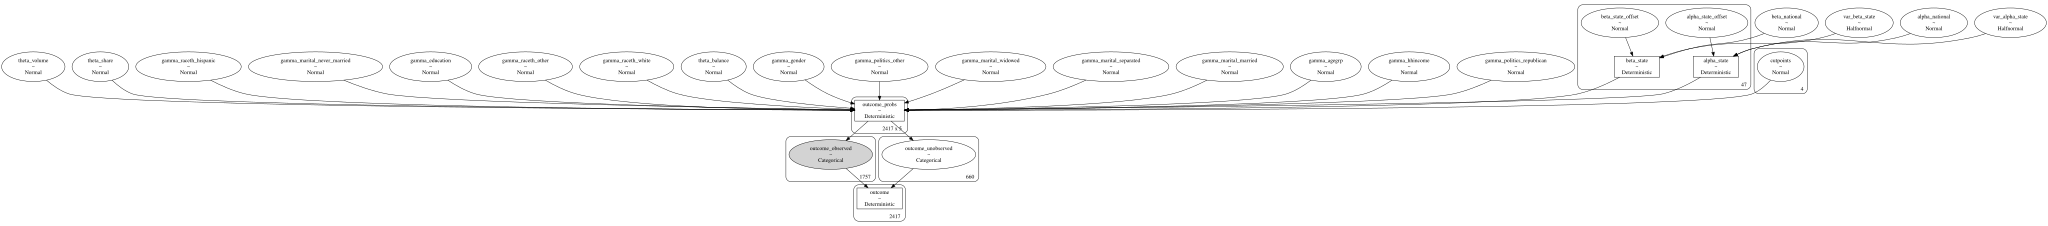

'cc_pgm_diagram.png'

In [23]:
import pymc as pm

# Number of States
n_states = cc["state_code"].nunique()

# Set up PGM
with pm.Model() as cc_model:

    #### Pooling Targets: National-Level Parameters
    # Avg. baseline opinion level across all states
    alpha_national = pm.Normal("alpha_national", 0, 2)
    
    # Avg. shift of opinion between waves across all states
    beta_national = pm.Normal("beta_national", 0, 2)
    
    # Causal Parameters (Dose Variables)
    # Strength of volume and balance metrics' relation to size of a state's opinion shift
    # Prior for sigma: since metrics are normalized, going with sigma = 1
    theta_volume = pm.Normal("theta_volume", 0, 1)
    theta_share = pm.Normal("theta_share", 0, 1)
    theta_balance = pm.Normal("theta_balance", 0, 1)

    # State vs. National Variance Parameters (to use in state-level parameters)
    var_alpha_state = pm.HalfNormal("var_alpha_state", 1)
    var_beta_state = pm.HalfNormal("var_beta_state", 1)

    
    #### Partial Pooling: State-Level 
    # Both will be using non-centered parameterization in order to standardize and accommodate for smaller number of respondents for some states
    # Baseline opinion level per state (pulled from distribution centered on the national average)
    alpha_state_offset = pm.Normal("alpha_state_offset", 0, 1, shape = n_states)
    alpha_state = pm.Deterministic("alpha_state", alpha_national + alpha_state_offset * var_alpha_state)
    
    # Shift of opinion between waves per state (pulled from distribution centered on the national average)
    beta_state_offset = pm.Normal("beta_state_offset", 0, 1, shape = n_states)
    beta_state = pm.Deterministic("beta_state", beta_national + beta_state_offset * var_beta_state)  

    
    #### Demographic Controls
    # Nominal categorical cols:
        # 'politics_Other', 'politics_Republican', 
        # 'marital_text_Married', 'marital_text_Never married', 'marital_text_Separated', 'marital_text_Widowed', 
        # 'raceth_Hispanic', 'raceth_Other', 'raceth_White'
    # Politics
    gamma_politics_republican = pm.Normal("gamma_politics_republican", 0, 1)
    gamma_politics_other = pm.Normal("gamma_politics_other", 0, 1)
    # Gender
    gamma_gender = pm.Normal("gamma_gender", 0, 1)
    # Marital Status
    gamma_marital_married = pm.Normal("gamma_marital_married", 0, 1)
    gamma_marital_never_married = pm.Normal("gamma_marital_never_married", 0, 1)
    gamma_marital_separated = pm.Normal("gamma_marital_separated", 0, 1)
    gamma_marital_widowed = pm.Normal("gamma_marital_widowed", 0, 1)
    # Race/Ethnicity
    gamma_raceth_hispanic = pm.Normal("gamma_raceth_hispanic", 0, 1)
    gamma_raceth_other = pm.Normal("gamma_raceth_other", 0, 1)
    gamma_raceth_white = pm.Normal("gamma_raceth_white", 0, 1)  
    
    # Ordinal categorical cols:
    # Age Grp
    gamma_agegrp = pm.Normal("gamma_agegrp", 0, 1)
    # Education Status
    gamma_education = pm.Normal("gamma_education", 0, 1)
    # Household Income
    gamma_hhincome = pm.Normal("gamma_hhincome", 0, 1)


    #### Set up Linear Predictor
    # Linear Regression: eta = beta_0 + (beta_1 * x_1) + (beta_2 * x_2) + ... 
    eta = (alpha_state[cc["state_code"].values] # State's baseline opinion level
            + (beta_state[cc["state_code"].values] * cc["wave_code"].values) # State's avg wave shift for opinion level
            + (theta_volume * cc["volume_z"].values * cc["wave_code"].values) # Dose * Wave for volume shift
            + (theta_balance * cc["balance_z"].values * cc["wave_code"].values) # Dose * Wave for framing balance shift
            + (theta_share * cc["share_z"].values * cc["wave_code"].values) # Dose * Wave for share of coverage shift
            + (gamma_politics_republican * cc["politics_Republican"].values.astype(float))
            + (gamma_politics_other * cc["politics_Other"].values.astype(float))
            + (gamma_gender * cc["gender"].values)
            + (gamma_marital_married * cc["marital_text_Married"].values.astype(float))
            + (gamma_marital_never_married * cc["marital_text_Never married"].values.astype(float))
            + (gamma_marital_separated * cc["marital_text_Separated"].values.astype(float))
            + (gamma_marital_widowed * cc["marital_text_Widowed"].values.astype(float))
            + (gamma_raceth_hispanic * cc["raceth_Hispanic"].values.astype(float))
            + (gamma_raceth_other * cc["raceth_Other"].values.astype(float))
            + (gamma_raceth_white * cc["raceth_White"].values.astype(float))
            + (gamma_agegrp * cc["agegrp"].values)
            + (gamma_education * cc["education"].values)
            + (gamma_hhincome * cc["hhincome"].values)
           )

    #### Outcomes
    ## cc_cause = primary outcome; 5-category ordinal
    ## cc_happening = seconday/robustness outcome; 3-category ordinal outcome
    
    # Set up Cutpoints
    # Since cc_cause is ordinal and not continuous, will use link function logit @ each cutpoint k
    cc_cutpoints = pm.Normal("cutpoints", 
                             mu = np.linspace(-2, 2, 4), 
                             sigma = 1, 
                             shape = 4, 
                             transform = pm.distributions.transforms.ordered)

    
    # Ordinal Likelihood via OrderedLogistic: 
    ## cc_cause = primary outcome; 5-category ordinal
    ## cc_happening = seconday/robustness outcome; 3-category ordinal outcome
    cc_outcome = pm.OrderedLogistic("outcome", 
                                    eta = eta, 
                                    cutpoints = cc_cutpoints,  
                                    observed = cc["cc_cause"].values)

    # Posterior Sampling
    trace = pm.sample(2000, 
                      tune = 2000, 
                      target_accept = 0.95, 
                      chains = 4)
    

# Produce PGM diagram for cc_model
cc_graph = pm.model_to_graphviz(cc_model)
display(cc_graph)

# Save PGM diagram as .png file
cc_graph.render("cc_pgm_diagram", format = "png")

In [24]:
# Prior Predictive Check (before sampling on real data)
with cc_model:
    cc_prior_pred = pm.sample_prior_predictive(draws = 500)

Sampling: [alpha_national, alpha_state_offset, beta_national, beta_state_offset, cutpoints, gamma_agegrp, gamma_education, gamma_gender, gamma_hhincome, gamma_marital_married, gamma_marital_never_married, gamma_marital_separated, gamma_marital_widowed, gamma_politics_other, gamma_politics_republican, gamma_raceth_hispanic, gamma_raceth_other, gamma_raceth_white, outcome_observed, outcome_unobserved, theta_balance, theta_share, theta_volume, var_alpha_state, var_beta_state]


In [25]:
# Pull simulated.predicted outcomes from the prior predictive
cc_prior_outcomes = cc_prior_pred.prior_predictive["outcome_observed"].values.flatten()
print(np.unique(cc_prior_outcomes, return_counts = True))

(array([0, 1, 2, 3, 4]), array([323923,  65425,  70839,  70554, 347759]))


Let's check on the priors

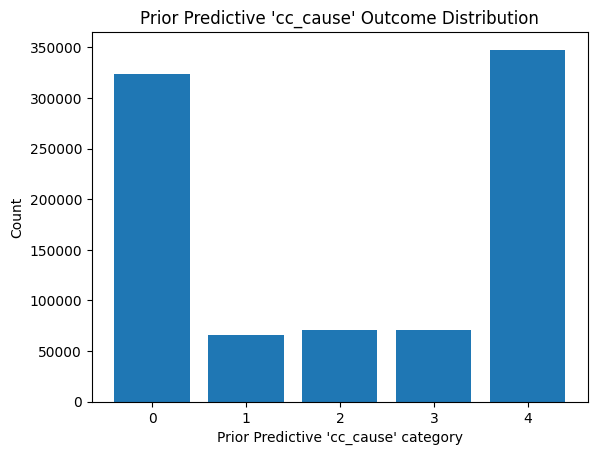

In [26]:
plt.hist(cc_prior_outcomes, bins = np.arange(-0.5, 5.5, 1), rwidth = 0.8)
plt.xlabel("Prior Predictive 'cc_cause' category")
plt.ylabel("Count")
plt.title("Prior Predictive 'cc_cause' Outcome Distribution")
plt.show()

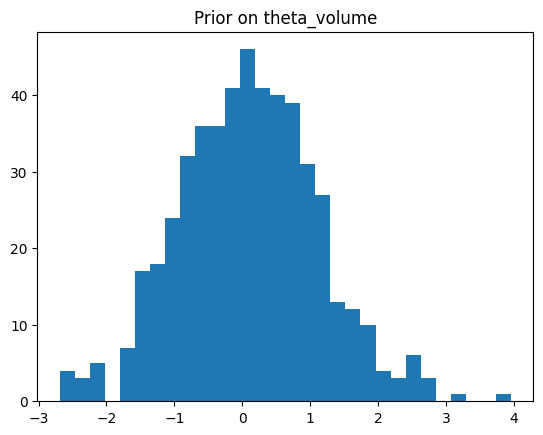

In [27]:
# 
cc_prior_theta_volume = cc_prior_pred.prior["theta_volume"].values.flatten()
plt.hist(cc_prior_theta_volume, bins = 30)
plt.title("Prior on theta_volume")
plt.show()

The bell curve shape of the above histogram, centered at 0, indicates that the prior sigma set in the design of the model is reasonable. 

In [29]:
import arviz as az

# Check to see if the parameterization worked or if you need to switch to non-centered parameterization
print(trace.sample_stats.diverging.sum().item())

0


In [30]:
# Summary
display(az.summary(trace, var_names = ["theta_volume", "theta_share", "theta_balance"]))

# checking for R-hat, ESS, divergences

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
theta_volume,0.021,0.08,-0.1,0.15,5558,5934,1.00,0.0011,0.00079
theta_share,0.047,0.084,-0.087,0.18,4864,5273,1.00,0.0012,0.00092
theta_balance,0.042,0.081,-0.088,0.17,6291,6460,1.00,0.001,0.00077


In [31]:
for param in ["theta_volume", "theta_share", "theta_balance"]:
    prob_positive = (trace.posterior[param] > 0).mean().item()
    print(f"P({param} > 0): {prob_positive:.3f}")

P(theta_volume > 0): 0.600
P(theta_share > 0): 0.722
P(theta_balance > 0): 0.700


<b>Findings:</b>

- With R-hat equal to 1.00 for the three parameters, we can say that the chains converged well and agree with each other.

- ESS_Bulk and ESS_Tail are both large enough and indicate that there is a reasonable inference to be made here.

- Mean of <b>theta_share</b> and <b>theta_balance</b> is higher than that of <b>theta_volume</b>, but they are still not as confident as one would prefer and the 87% credible interval for all three (formed from eti89_lm, eti89_ub) contain 0.
    - This means that <b>theta_volume</b> cannot be confidently used to conclude that raw volume of coverage of climate change articles has any influence on the shift of attitudes toward the cause of climate change being human-made as opposed to natural.
    - We also find that <b>theta_share</b> and <b>theta_balance</b> have a 72% and 70%, respectively, probability of being positive.

While there doesn't seem to be a strong confident effect shown by any of the metrics, there is still a noticable shift toward our theorized stance.

Sampling: [outcome_observed]


Output()

/opt/tljh/user/lib/python3.12/site-packages/arviz_plots/plots/utils_ppc.py:66: UserWarning: Detected at least one discrete variable.
Consider using plot_ppc variants specific for discrete data, such as plot_ppc_pava or plot_ppc_rootogram.
  warn_if_discrete(observed_dist, predictive_dist, kind)


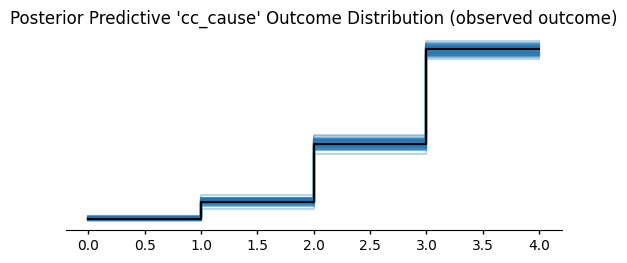

In [32]:
# Posterior Predictive Check
with cc_model: 
    cc_ppc = pm.sample_posterior_predictive(trace)

az.plot_ppc_dist(cc_ppc, var_names = ["outcome_observed"])
plt.title("Posterior Predictive 'cc_cause' Outcome Distribution (observed outcome)")
plt.show()

Above we see that the observed data line (in black) is within the spread of the simulated posterior predictive draws.

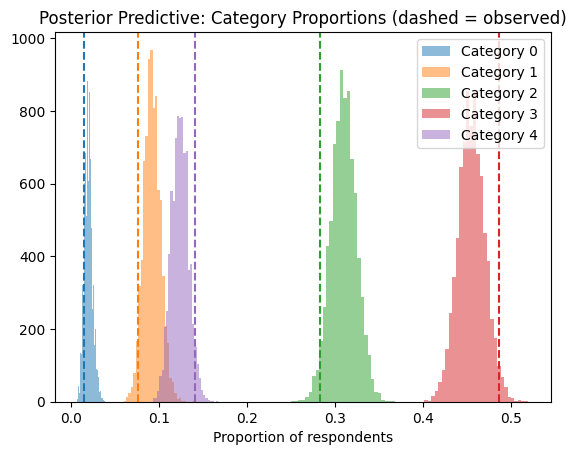

In [34]:
# Single out the observed section (i.e. non-nans)
observed = pd.Series(cc["cc_cause"].dropna()).value_counts(normalize=True).sort_index()

# Extract posterior predictive draws for only the observed dataset now
# NOTE: Used Claude.AI for the below
ppc_samples = cc_ppc.posterior_predictive["outcome"].values.reshape(-1, len(cc))
ppc_proportions = np.array([(ppc_samples == cat).mean(axis = 1) for cat in range(5)])

fig, ax = plt.subplots()
for cat in range(5):
    ax.hist(ppc_proportions[cat], bins = 30, alpha = 0.5, label = f"Category {cat}")
    ax.axvline(observed.get(cat, 0), color = f"C{cat}", linestyle = "--")
ax.legend()
ax.set_xlabel("Proportion of respondents")
ax.set_title("Posterior Predictive: Category Proportions (dashed = observed)")
plt.show()


In the above we see that 

Next: a shrinkage check to compare every state's raw mean vs. the employed model's pooled posterior estimate. The goal is to understand if Partial Pooling is working.

Shrinkage is a technique that pulls noisy quantities (due to being calculated/estimated at an individual level) toward a group-based value like a group mean or a group prediction from a model in an effort to reduce variance. 

This is particularly useful in this project because of how some states have a few respondents whiel others have many. Shrinkage will help pull the estimates of the states with few respondents toward the overall effect being studied. 

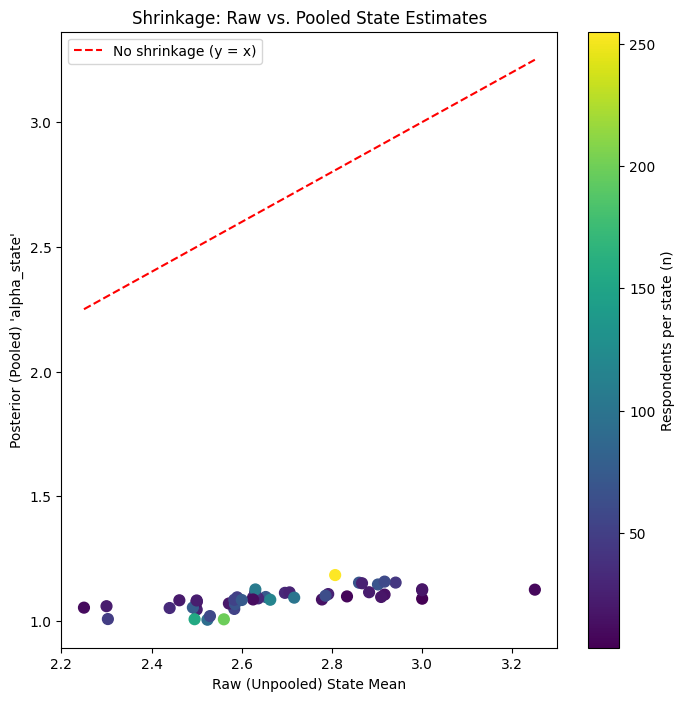

In [35]:
# Validation: Shrinkage check
# compare raw per-state means vs. posterior alpha_state/beta_state and confirm that small-n states show more shrinkage

# Single out raw means per state for cc_cause
raw_state_means = cc.groupby("state_code")["cc_cause"].mean()

# Posterior mean of alpha_state per state (Pooled Estimate)
posterior_alpha_state = trace.posterior["alpha_state"].mean(dim = ["chain", "draw"]).values

# State sample sizes
state_n = cc.groupby("state_code").size()

# Shrinkage plot
fig, ax = plt.subplots(figsize = (8, 8))
sc = ax.scatter(raw_state_means, posterior_alpha_state, c = state_n, cmap = "viridis", s = 60)
ax.plot([raw_state_means.min(), raw_state_means.max()], [raw_state_means.min(), raw_state_means.max()], 
        color = "red", linestyle = "--",label = "No shrinkage (y = x)")
plt.colorbar(sc, label = "Respondents per state (n)")
ax.set_xlabel("Raw (Unpooled) State Mean")
ax.set_ylabel("Posterior (Pooled) 'alpha_state'")
ax.set_title("Shrinkage: Raw vs. Pooled State Estimates")
ax.legend()
plt.show()


### Sensitivity Checks/Robustness

There are 660 missing values in the outcome, "cc_cause," column. So let's try to remove them and see how the model is affected then.

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha_national, beta_national, theta_volume, theta_share, theta_balance, var_alpha_state, var_beta_state, alpha_state_offset, beta_state_offset, gamma_politics_republican, gamma_politics_other, gamma_gender, gamma_marital_married, gamma_marital_never_married, gamma_marital_separated, gamma_marital_widowed, gamma_raceth_hispanic, gamma_raceth_other, gamma_raceth_white, gamma_agegrp, gamma_education, gamma_hhincome, cutpoints]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 132 seconds.


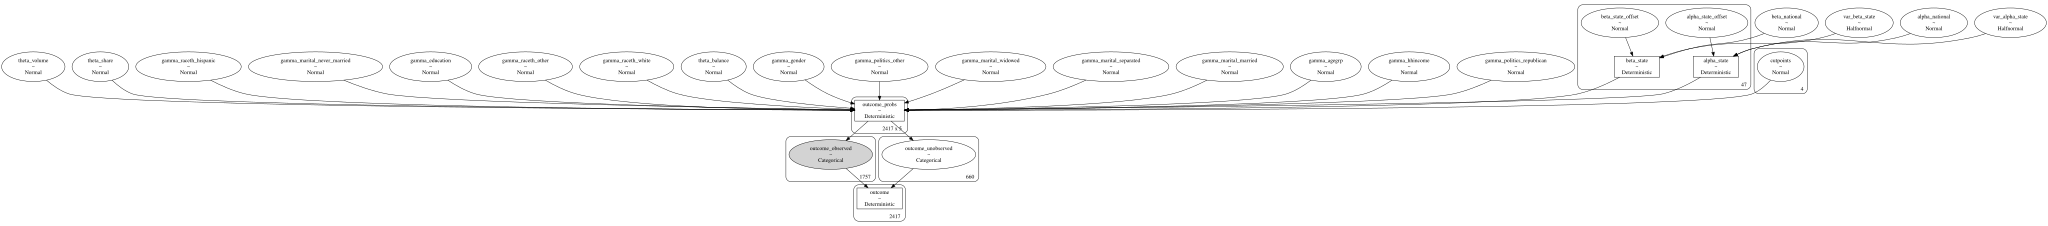

'cc_pgm_diagram.png'

In [36]:
# Sensitivity checks 

# 660 missing values in the cc_cause col
# refit the model on a dataset that has removed these rows 
# see if theta estimates change between the two verison
# note if there is a change
cc_complete = cc.dropna(subset=["cc_cause"]).copy()

cc_complete["volume_z"] = (cc_complete["volume_by_state_wave"] - cc_complete["volume_by_state_wave"].mean()) / cc_complete["volume_by_state_wave"].std()
cc_complete["balance_z"] = (cc_complete["balance"] - cc_complete["balance"].mean()) / cc_complete["balance"].std()
cc_complete["share_z"] = (cc_complete["coverage_share"] - cc_complete["coverage_share"].mean()) / cc_complete["coverage_share"].std()

n_states_complete = cc_complete["state_code"].nunique()

with pm.Model() as cc_model_complete:
    #### Pooling Targets: National-Level Parameters
    # Avg. baseline opinion level across all states
    alpha_national = pm.Normal("alpha_national", 0, 2)
    
    # Avg. shift of opinion between waves across all states
    beta_national = pm.Normal("beta_national", 0, 2)
    
    # Causal Parameters (Dose Variables)
    # Strength of volume and balance metrics' relation to size of a state's opinion shift
    # Prior for sigma: since metrics are normalized, going with sigma = 1
    theta_volume = pm.Normal("theta_volume", 0, 1)
    theta_share = pm.Normal("theta_share", 0, 1)
    theta_balance = pm.Normal("theta_balance", 0, 1)

    # State vs. National Variance Parameters (to use in state-level parameters)
    var_alpha_state = pm.HalfNormal("var_alpha_state", 1)
    var_beta_state = pm.HalfNormal("var_beta_state", 1)

    
    #### Partial Pooling: State-Level 
    # Both will be using non-centered parameterization in order to standardize and accommodate for smaller number of respondents for some states
    # Baseline opinion level per state (pulled from distribution centered on the national average)
    alpha_state_offset = pm.Normal("alpha_state_offset", 0, 1, shape = n_states_complete)
    alpha_state = pm.Deterministic("alpha_state", alpha_national + alpha_state_offset * var_alpha_state)
    
    # Shift of opinion between waves per state (pulled from distribution centered on the national average)
    beta_state_offset = pm.Normal("beta_state_offset", 0, 1, shape = n_states_complete)
    beta_state = pm.Deterministic("beta_state", beta_national + beta_state_offset * var_beta_state)  

    
    #### Demographic Controls
    # Nominal categorical cols:
        # 'politics_Other', 'politics_Republican', 
        # 'marital_text_Married', 'marital_text_Never married', 'marital_text_Separated', 'marital_text_Widowed', 
        # 'raceth_Hispanic', 'raceth_Other', 'raceth_White'
    # Politics
    gamma_politics_republican = pm.Normal("gamma_politics_republican", 0, 1)
    gamma_politics_other = pm.Normal("gamma_politics_other", 0, 1)
    # Gender
    gamma_gender = pm.Normal("gamma_gender", 0, 1)
    # Marital Status
    gamma_marital_married = pm.Normal("gamma_marital_married", 0, 1)
    gamma_marital_never_married = pm.Normal("gamma_marital_never_married", 0, 1)
    gamma_marital_separated = pm.Normal("gamma_marital_separated", 0, 1)
    gamma_marital_widowed = pm.Normal("gamma_marital_widowed", 0, 1)
    # Race/Ethnicity
    gamma_raceth_hispanic = pm.Normal("gamma_raceth_hispanic", 0, 1)
    gamma_raceth_other = pm.Normal("gamma_raceth_other", 0, 1)
    gamma_raceth_white = pm.Normal("gamma_raceth_white", 0, 1)  
    
    # Ordinal categorical cols:
    # Age Grp
    gamma_agegrp = pm.Normal("gamma_agegrp", 0, 1)
    # Education Status
    gamma_education = pm.Normal("gamma_education", 0, 1)
    # Household Income
    gamma_hhincome = pm.Normal("gamma_hhincome", 0, 1)


    #### Set up Linear Predictor
    # Linear Regression: eta = beta_0 + (beta_1 * x_1) + (beta_2 * x_2) + ... 
    eta = (alpha_state[cc_complete["state_code"].values] # State's baseline opinion level
            + (beta_state[cc_complete["state_code"].values] * cc_complete["wave_code"].values) # State's avg wave shift for opinion level
            + (theta_volume * cc_complete["volume_z"].values * cc_complete["wave_code"].values) # Dose * Wave for volume shift
            + (theta_balance * cc_complete["balance_z"].values * cc_complete["wave_code"].values) # Dose * Wave for framing balance shift
            + (theta_share * cc_complete["share_z"].values * cc_complete["wave_code"].values) # Dose * Wave for share of coverage shift
            + (gamma_politics_republican * cc_complete["politics_Republican"].values.astype(float))
            + (gamma_politics_other * cc_complete["politics_Other"].values.astype(float))
            + (gamma_gender * cc_complete["gender"].values)
            + (gamma_marital_married * cc_complete["marital_text_Married"].values.astype(float))
            + (gamma_marital_never_married * cc_complete["marital_text_Never married"].values.astype(float))
            + (gamma_marital_separated * cc_complete["marital_text_Separated"].values.astype(float))
            + (gamma_marital_widowed * cc_complete["marital_text_Widowed"].values.astype(float))
            + (gamma_raceth_hispanic * cc_complete["raceth_Hispanic"].values.astype(float))
            + (gamma_raceth_other * cc_complete["raceth_Other"].values.astype(float))
            + (gamma_raceth_white * cc_complete["raceth_White"].values.astype(float))
            + (gamma_agegrp * cc_complete["agegrp"].values)
            + (gamma_education * cc_complete["education"].values)
            + (gamma_hhincome * cc_complete["hhincome"].values)
           )

    #### Outcomes
    ## cc_cause = primary outcome; 5-category ordinal
    ## cc_happening = seconday/robustness outcome; 3-category ordinal outcome
    
    # Set up Cutpoints
    # Since cc_cause is ordinal and not continuous, will use link function logit @ each cutpoint k
    cc_cutpoints = pm.Normal("cutpoints", 
                             mu = np.linspace(-2, 2, 4), 
                             sigma = 1, 
                             shape = 4, 
                             transform = pm.distributions.transforms.ordered)

    
    # Ordinal Likelihood via OrderedLogistic: 
    ## cc_cause = primary outcome; 5-category ordinal
    ## cc_happening = seconday/robustness outcome; 3-category ordinal outcome
    cc_outcome = pm.OrderedLogistic("outcome", 
                                    eta = eta, 
                                    cutpoints = cc_cutpoints,  
                                    observed = cc_complete["cc_cause"].values)

    # Posterior Sampling
    trace_complete = pm.sample(2000, 
                      tune = 2000, 
                      target_accept = 0.95, 
                      chains = 4)
    

# Produce PGM diagram for cc_model
cc_graph = pm.model_to_graphviz(cc_model)
display(cc_graph)

# Save PGM diagram as .png file
cc_graph.render("cc_pgm_diagram", format = "png")

Sampling: [alpha_national, alpha_state_offset, beta_national, beta_state_offset, cutpoints, gamma_agegrp, gamma_education, gamma_gender, gamma_hhincome, gamma_marital_married, gamma_marital_never_married, gamma_marital_separated, gamma_marital_widowed, gamma_politics_other, gamma_politics_republican, gamma_raceth_hispanic, gamma_raceth_other, gamma_raceth_white, outcome, theta_balance, theta_share, theta_volume, var_alpha_state, var_beta_state]


(array([0, 1, 2, 3, 4]), array([364731,  64072,  71723,  65564, 312410]))


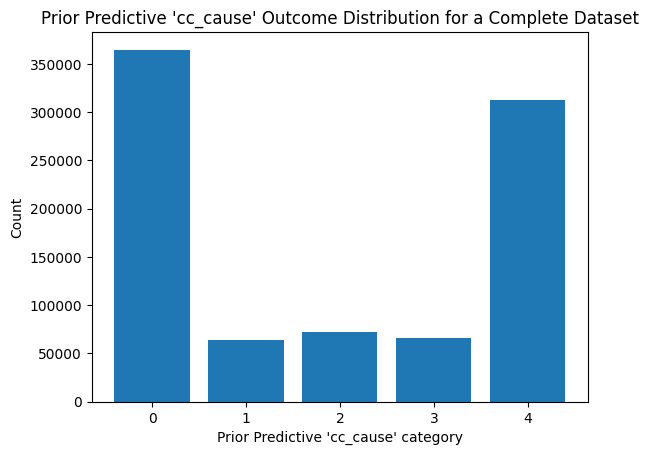

In [38]:
# Prior Predictive Check (before sampling on real data)
with cc_model_complete:
    cc_prior_pred_complete = pm.sample_prior_predictive(draws = 500)

# Pull simulated.predicted outcomes from the prior predictive
cc_prior_outcomes_complete = cc_prior_pred_complete.prior_predictive["outcome"].values.flatten()
print(np.unique(cc_prior_outcomes_complete, return_counts = True))

# Plot
plt.hist(cc_prior_outcomes_complete, bins = np.arange(-0.5, 5.5, 1), rwidth = 0.8)
plt.xlabel("Prior Predictive 'cc_cause' category")
plt.ylabel("Count")
plt.title("Prior Predictive 'cc_cause' Outcome Distribution for a Complete Dataset")
plt.show()

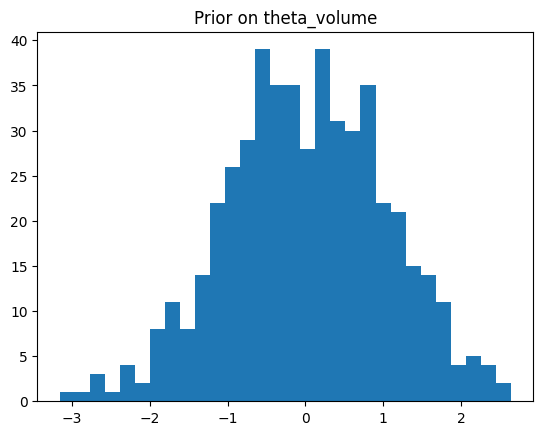

In [39]:
cc_prior_theta_volume_comp = cc_prior_pred_complete.prior["theta_volume"].values.flatten()
plt.hist(cc_prior_theta_volume_comp, bins = 30)
plt.title("Prior on theta_volume")
plt.show()

In [40]:
print(trace_complete.sample_stats.diverging.sum().item())

display(az.summary(trace_complete, var_names = ["theta_volume", "theta_share", "theta_balance"]))


0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
theta_volume,0.022,0.081,-0.11,0.15,3793,4371,1.00,0.0013,0.00098
theta_share,0.046,0.085,-0.09,0.18,3731,4636,1.00,0.0014,0.001
theta_balance,0.042,0.081,-0.087,0.17,4349,5225,1.00,0.0012,0.00087


Taking a look at the means of the metrics, not much has changed with removing the missing values from the outcome variable (cc_cause) in the dataset.

Let's try using a different outcome variable: Instead of looking at the influence of local news coverage on climate change on the shift of opinion on the cause of climate change being natural to human-made, let's try to see if there's an influence on whether climate change is happening at all or not.

/opt/tljh/user/lib/python3.12/site-packages/pymc/model/core.py:1323: RuntimeWarning: invalid value encountered in cast
  data = convert_observed_data(data).astype(rv_var.dtype)
/opt/tljh/user/lib/python3.12/site-packages/pymc/model/core.py:1337: ImputationWarning: Data in outcome contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [alpha_national, beta_national, theta_volume, theta_share, theta_balance, var_alpha_state, var_beta_state, alpha_state_offset, beta_state_offset, gamma_politics_republican, gamma_politics_other, gamma_gender, gamma_marital_married, gamma_marital_never_married, gamma_marital_separated, gamma_marital_widowed, gamma_raceth_hispanic, gamma_raceth_other, gamma_raceth_white, gamma_agegrp, gamma_education, gamma_hhincome, cutpoints]
>CategoricalGibbsMetropolis: [outcome_unobserved]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 276 seconds.


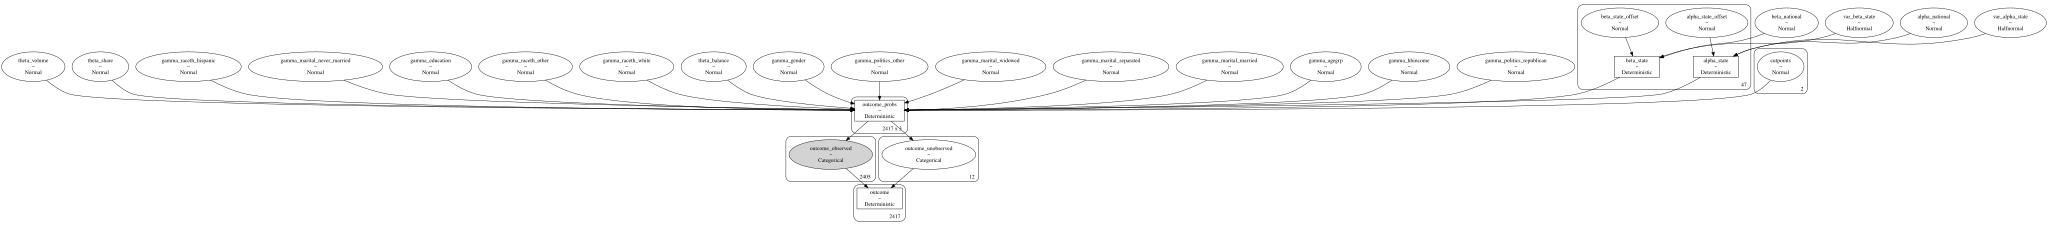

'cc_happening_pgm_diagram.png'

In [42]:
# Let's try using cc_happening instead of cc_cause as the outcome variable

# cc_happening = 3-category ordinal outcome (0 = not happening, 1 = not sure, 2 = happening)

n_states = cc["state_code"].nunique()  # full dataset, same as your original cc_model

with pm.Model() as cc_happening_model:
    #### Pooling Targets: National-Level Parameters
    alpha_national = pm.Normal("alpha_national", 0, 2)
    beta_national = pm.Normal("beta_national", 0, 2)
    
    # Causal Parameters (Dose Variables)
    theta_volume = pm.Normal("theta_volume", 0, 1)
    theta_share = pm.Normal("theta_share", 0, 1)
    theta_balance = pm.Normal("theta_balance", 0, 1)

    # State vs. National Variance Parameters
    var_alpha_state = pm.HalfNormal("var_alpha_state", 1)
    var_beta_state = pm.HalfNormal("var_beta_state", 1)

    #### Partial Pooling: State-Level (non-centered)
    alpha_state_offset = pm.Normal("alpha_state_offset", 0, 1, shape=n_states)
    alpha_state = pm.Deterministic("alpha_state", alpha_national + alpha_state_offset * var_alpha_state)
    
    beta_state_offset = pm.Normal("beta_state_offset", 0, 1, shape=n_states)
    beta_state = pm.Deterministic("beta_state", beta_national + beta_state_offset * var_beta_state)

    #### Demographic Controls
    gamma_politics_republican = pm.Normal("gamma_politics_republican", 0, 1)
    gamma_politics_other = pm.Normal("gamma_politics_other", 0, 1)
    gamma_gender = pm.Normal("gamma_gender", 0, 1)
    gamma_marital_married = pm.Normal("gamma_marital_married", 0, 1)
    gamma_marital_never_married = pm.Normal("gamma_marital_never_married", 0, 1)
    gamma_marital_separated = pm.Normal("gamma_marital_separated", 0, 1)
    gamma_marital_widowed = pm.Normal("gamma_marital_widowed", 0, 1)
    gamma_raceth_hispanic = pm.Normal("gamma_raceth_hispanic", 0, 1)
    gamma_raceth_other = pm.Normal("gamma_raceth_other", 0, 1)
    gamma_raceth_white = pm.Normal("gamma_raceth_white", 0, 1)  
    gamma_agegrp = pm.Normal("gamma_agegrp", 0, 1)
    gamma_education = pm.Normal("gamma_education", 0, 1)
    gamma_hhincome = pm.Normal("gamma_hhincome", 0, 1)

    #### Linear Predictor
    eta = (alpha_state[cc["state_code"].values]
            + (beta_state[cc["state_code"].values] * cc["wave_code"].values)
            + (theta_volume * cc["volume_z"].values * cc["wave_code"].values)
            + (theta_balance * cc["balance_z"].values * cc["wave_code"].values)
            + (theta_share * cc["share_z"].values * cc["wave_code"].values)
            + (gamma_politics_republican * cc["politics_Republican"].values.astype(float))
            + (gamma_politics_other * cc["politics_Other"].values.astype(float))
            + (gamma_gender * cc["gender"].values)
            + (gamma_marital_married * cc["marital_text_Married"].values.astype(float))
            + (gamma_marital_never_married * cc["marital_text_Never married"].values.astype(float))
            + (gamma_marital_separated * cc["marital_text_Separated"].values.astype(float))
            + (gamma_marital_widowed * cc["marital_text_Widowed"].values.astype(float))
            + (gamma_raceth_hispanic * cc["raceth_Hispanic"].values.astype(float))
            + (gamma_raceth_other * cc["raceth_Other"].values.astype(float))
            + (gamma_raceth_white * cc["raceth_White"].values.astype(float))
            + (gamma_agegrp * cc["agegrp"].values)
            + (gamma_education * cc["education"].values)
            + (gamma_hhincome * cc["hhincome"].values)
           )

    #### Outcome: cc_happening (3 categories; 2 cutpoints)
    cc_happening_cutpoints = pm.Normal("cutpoints", 
                             mu=np.linspace(-1, 1, 2),
                             sigma=1, 
                             shape=2,
                             transform=pm.distributions.transforms.ordered)

    # observed= includes NaNs
    cc_happening_outcome = pm.OrderedLogistic("outcome", 
                                    eta=eta, 
                                    cutpoints=cc_happening_cutpoints,  
                                    observed=cc["cc_happening"].values)

    trace_happening = pm.sample(2000, 
                      tune=2000, 
                      target_accept=0.95, 
                      chains=4)

# PGM diagram
cc_happening_graph = pm.model_to_graphviz(cc_happening_model)
display(cc_happening_graph)
cc_happening_graph.render("cc_happening_pgm_diagram", format="png")

Sampling: [alpha_national, alpha_state_offset, beta_national, beta_state_offset, cutpoints, gamma_agegrp, gamma_education, gamma_gender, gamma_hhincome, gamma_marital_married, gamma_marital_never_married, gamma_marital_separated, gamma_marital_widowed, gamma_politics_other, gamma_politics_republican, gamma_raceth_hispanic, gamma_raceth_other, gamma_raceth_white, outcome_observed, outcome_unobserved, theta_balance, theta_share, theta_volume, var_alpha_state, var_beta_state]


(array([0, 1, 2]), array([535547, 149909, 517044]))


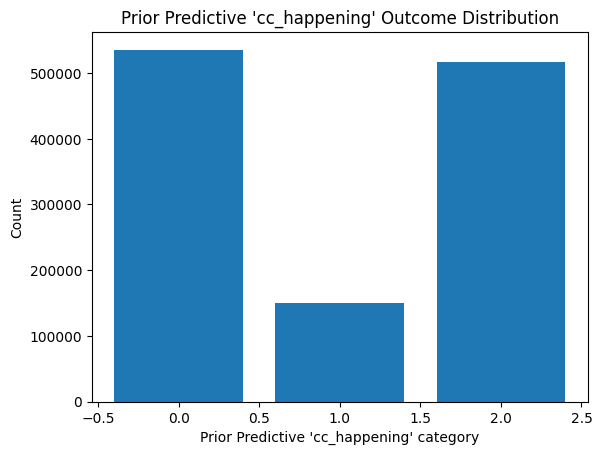

In [45]:
# Prior Predictive Check (before sampling on real data)
with cc_happening_model:
    cc_prior_pred_hap = pm.sample_prior_predictive(draws = 500)

# Pull simulated.predicted outcomes from the prior predictive
cc_prior_outcomes_hap = cc_prior_pred_hap.prior_predictive["outcome_observed"].values.flatten()
print(np.unique(cc_prior_outcomes_hap, return_counts = True))

# Plot
plt.hist(cc_prior_outcomes_hap, bins=np.arange(-0.5, 3.5, 1), rwidth=0.8)
plt.xlabel("Prior Predictive 'cc_happening' category")
plt.ylabel("Count")
plt.title("Prior Predictive 'cc_happening' Outcome Distribution")
plt.show()

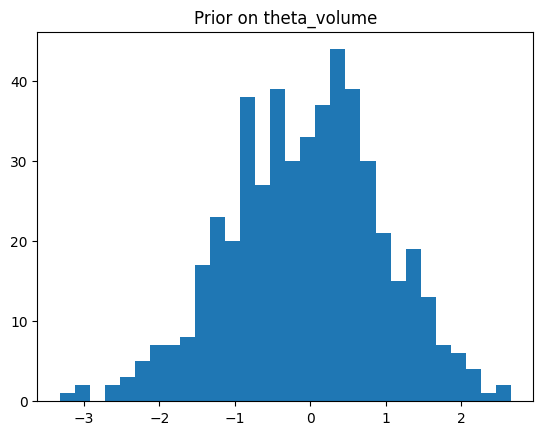

In [47]:
cc_prior_theta_share_hap = cc_prior_pred_hap.prior["theta_share"].values.flatten()
plt.hist(cc_prior_theta_share_hap, bins = 30)
plt.title("Prior on theta_share")
plt.show()

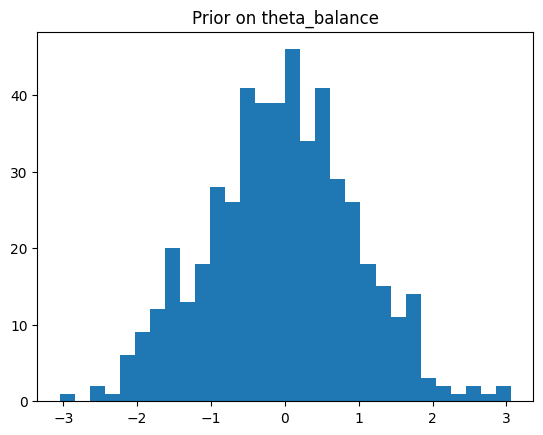

In [49]:
cc_prior_theta_balance_hap = cc_prior_pred_hap.prior["theta_balance"].values.flatten()
plt.hist(cc_prior_theta_balance_hap, bins = 30)
plt.title("Prior on theta_balance")
plt.show()

In [50]:
print(trace_happening.sample_stats.diverging.sum().item())

display(az.summary(trace_happening, var_names = ["theta_volume", "theta_share", "theta_balance"]))


0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
theta_volume,0.089,0.085,-0.047,0.22,10987,6879,1.00,0.00081,0.00061
theta_share,-0.098,0.089,-0.24,0.042,9637,6689,1.00,0.00091,0.00067
theta_balance,0.017,0.092,-0.13,0.17,10426,6387,1.00,0.0009,0.00066


<b>Findings:</b>

- With R-hat equal to 1.00 for the three parameters, we can say that the chains converged well and agree with each other.

- ESS_Bulk and ESS_Tail are both large enough and indicate that there is a reasonable inference to be made here. Note, however, that it is in the tens of thousands for <b>theta_volume</b> and <b>theta_balance</b>.

- The mean of <b>theta_volume</b> is the largest of the three metrics, meaning that when looking at public opinion on whether climate change is happening or not, raw volume of coverage is the strongest measure. On the other hand, <b>theta_share</b> is now negative, indicating that it has a weak, negative relationship between coverage share and the opinion on climate change happening. Lastly, <b>theta_balance</b> has stayed consistent.

- This is a stronger conclusion than that produced for cc_cause, but still not showing confident evidence for any influential relationship between any of the three metrics for local news coverage and the outcome variables.

While there doesn't seem to be a strong confident effect shown by any of the metrics, there is still a noticable shift toward our theorized stance.

Sampling: [outcome_observed]


Output()

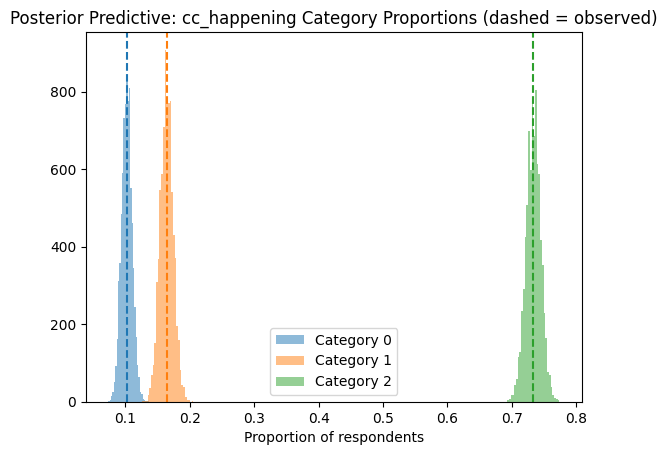

In [52]:
# First, generate the posterior predictive for the happening model
with cc_happening_model:
    cc_ppc_happening = pm.sample_posterior_predictive(trace_happening)

# Single out the observed section (i.e. non-nans)
observed_happening = pd.Series(cc["cc_happening"].dropna()).value_counts(normalize=True).sort_index()

# Extract posterior predictive draws for only the observed dataset now
ppc_samples_happening = cc_ppc_happening.posterior_predictive["outcome"].values.reshape(-1, len(cc))
ppc_proportions_happening = np.array([(ppc_samples_happening == cat).mean(axis=1) for cat in range(3)])

fig, ax = plt.subplots()
for cat in range(3):
    ax.hist(ppc_proportions_happening[cat], bins=30, alpha=0.5, label=f"Category {cat}")
    ax.axvline(observed_happening.get(cat, 0), color=f"C{cat}", linestyle="--")
ax.legend()
ax.set_xlabel("Proportion of respondents")
ax.set_title("Posterior Predictive: cc_happening Category Proportions (dashed = observed)")
plt.show()

This is visibly better than the cc_cause model. Thus, the fit of the model is good. 

### POTENTIAL EXTENSION: Robustness (Region-Level, State-Level Analysis)

Robustness is a technique to judge if the model would hold up under different conditions like changing variables, samples, estimators, etc.   

In [ ]:
# # Encode Census Region
# cc["region_code"] = cc["census_region_text"].astype("category").cat.codes

In [ ]:
# # Map each state to its region for down-the-line nesting purposes
# state_region_mapping = (cc.drop_duplicated("state")[["state_code", "region_code"]]
#                         .set_index("state_code")["region_code"]
#                         .to_dict())

# # Number of states/regions
# n_states = cc["state_code"].nunique()
# n_regions = cc["region_code"].nunique()

# # 
# region_per_state = np.array([state_region_mapping[s] for s in range(n_states)])


In [ ]:
# import pymc as pm

# # Set up PGM
# with pm.Model() as cc_reg_model:

#     #### Pooling Targets: National-Level Parameters
#     # Avg. baseline opinion level across all states
#     alpha_national = pm.Normal("alpha_national", 0, 2)
    
#     # Avg. shift of opinion between waves across all states
#     beta_national = pm.Normal("beta_national", 0, 2)
    
#     # Causal Parameters (Dose Variables)
#     # Strength of volume and balance metrics' relation to size of a state's opinion shift
#     # Prior for sigma: since metrics are normalized, going with sigma = 1
#     theta_volume = pm.Normal("theta_volume", 0, 1)
#     theta_balance = pm.Normal("theta_balance", 0, 1)

#     # State vs. National Variance Parameters (to use in state-level parameters)
#     var_alpha_state = pm.HalfNormal("var_alpha_state", 1)
#     var_beta_state = pm.HalfNormal("var_beta_state", 1)


#     #### Region-Level Parameters (non-centered)
#     # Region vs. National Variance Parameters
#     var_alpha_region = pm.HalfNormal("var_alpha_region", 1)
#     var_beta_region = pm.HalfNormal("var_beta_region", 1)
    
#     alpha_region_offset = pm.Normal("alpha_region", 0, 1, shape = n_regions)
    

    
#     #### Partial Pooling: State-Level 
#     # Baseline opinion level per state (pulled from distribution centered on the national average)
#     alpha_state = pm.Normal("alpha_state", 
#                             alpha_national, 
#                             var_alpha_state, 
#                             shape = n_states)
    
#     # Shift of opinion between waves per state (pulled from distribution centered on the national average)
#     beta_state = pm.Normal("beta_state", 
#                            beta_national, 
#                            var_beta_state, 
#                            shape = n_states)    

    
#     #### Demographic Controls
#     # Nominal categorical cols:
#         # 'politics_Other', 'politics_Republican', 
#         # 'marital_text_Married', 'marital_text_Never married', 'marital_text_Separated', 'marital_text_Widowed', 
#         # 'raceth_Hispanic', 'raceth_Other', 'raceth_White'
#     # Politics
#     gamma_politics_republican = pm.Normal("gamma_politics_republican", 0, 1)
#     gamma_politics_other = pm.Normal("gamma_politics_other", 0, 1)
#     # Gender
#     gamma_gender = pm.Normal("gamma_gender", 0, 1)
#     # Marital Status
#     gamma_marital_married = pm.Normal("gamma_marital_married", 0, 1)
#     gamma_marital_never_married = pm.Normal("gamma_marital_never_married", 0, 1)
#     gamma_marital_separated = pm.Normal("gamma_marital_separated", 0, 1)
#     gamma_marital_widowed = pm.Normal("gamma_marital_widowed", 0, 1)
#     # Race/Ethnicity
#     gamma_raceth_hispanic = pm.Normal("gamma_raceth_hispanic", 0, 1)
#     gamma_raceth_other = pm.Normal("gamma_raceth_other", 0, 1)
#     gamma_raceth_white = pm.Normal("gamma_raceth_white", 0, 1)  
    
#     # Ordinal categorical cols:
#     # Age Grp
#     gamma_agegrp = pm.Normal("gamma_agegrp", 0, 1)
#     # Education Status
#     gamma_education = pm.Normal("gamma_education", 0, 1)
#     # Household Income
#     gamma_hhincome = pm.Normal("gamma_hhincome", 0, 1)


#     #### Set up Linear Predictor
#     # Linear Regression: eta = beta_0 + (beta_1 * x_1) + (beta_2 * x_2) + ... 
#     eta = (alpha_state[cc["state_code"].values] # State's baseline opinion level
#             + (beta_state[cc["state_code"].values] * cc["wave_code"].values) # State's avg wave shift for opinion level
#             + (theta_volume * cc["volume_z"].values * cc["wave_code"].values) # Dose * Wave for volume shift
#             + (theta_balance * cc["balance_z"].values * cc["wave_code"].values) # Dose * Wave for framing balance shift
#             + (gamma_politics_republican * cc["politics_Republican"].values.astype(float))
#             + (gamma_politics_other * cc["politics_Other"].values.astype(float))
#             + (gamma_gender * cc["gender"].values)
#             + (gamma_marital_married * cc["marital_text_Married"].values.astype(float))
#             + (gamma_marital_never_married * cc["marital_text_Never married"].values.astype(float))
#             + (gamma_marital_separated * cc["marital_text_Separated"].values.astype(float))
#             + (gamma_marital_widowed * cc["marital_text_Widowed"].values.astype(float))
#             + (gamma_raceth_hispanic * cc["raceth_Hispanic"].values.astype(float))
#             + (gamma_raceth_other * cc["raceth_Other"].values.astype(float))
#             + (gamma_raceth_white * cc["raceth_White"].values.astype(float))
#             + (gamma_agegrp * cc["agegrp"].values)
#             + (gamma_education * cc["education"].values)
#             + (gamma_hhincome * cc["hhincome"].values)
#            )

#     #### Outcomes
#     ## cc_cause = primary outcome; 5-category ordinal
#     ## cc_happening = seconday/robustness outcome; 3-category ordinal outcome
    
#     # Set up Cutpoints
#     # Since cc_cause is ordinal and not continuous, will use link function logit @ each cutpoint k
#     cc_cutpoints = pm.Normal("cutpoints", 
#                              mu = np.linspace(-2, 2, 4), 
#                              sigma = 1, 
#                              shape = 4, 
#                              transform = pm.distributions.transforms.ordered)

    
#     # Ordinal Likelihood via OrderedLogistic: 
#     ## cc_cause = primary outcome; 5-category ordinal
#     ## cc_happening = seconday/robustness outcome; 3-category ordinal outcome
#     cc_outcome = pm.OrderedLogistic("outcome", 
#                                     eta = eta, 
#                                     cutpoints = cc_cutpoints,  
#                                     observed = cc["cc_cause"].values)

#     # Posterior Sampling
#     trace = pm.sample(2000, 
#                       tune = 2000, 
#                       target_accept = 0.95, 
#                       chains = 4)
    

# # Produce PGM diagram for cc_model
# cc_graph = pm.model_to_graphviz(cc_model)
# display(cc_graph)

# # Save PGM diagram as .png file
# cc_graph.render("cc_pgm_diagram", format = "png")